In [1]:
import numpy as np
from aeon.transformations.collection.convolution_based import MultiRocket
from aeon.transformations.collection.convolution_based._hydra import HydraTransformer
from aeon.utils.validation import check_n_jobs
from aeon.transformations.collection.interval_based import QUANTTransformer
import numpy as np
import polars as pl
from aeon.classification.base import BaseClassifier
from aeon.classification.feature_based import (
    Catch22Classifier,
)
import os
from aeon.transformations.collection.convolution_based import Rocket
from aeon.datasets.tsc_datasets import univariate
from sklearn.base import clone
from aeon.classification.convolution_based import MultiRocketHydraClassifier
from aeon.classification.convolution_based import RocketClassifier
from sklearn.metrics import accuracy_score
from aeon.classification.interval_based import QUANTClassifier
from autotsc import utils, models, transformers
from tqdm import tqdm
from aeon.classification.feature_based import Catch22Classifier
from aeon.classification.interval_based import QUANTClassifier
from aeon.classification.shapelet_based import RDSTClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeClassifierCV
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from aeon.pipeline import make_pipeline as aeon_make_pipeline
from aeon.transformations.collection import Normalizer
import seaborn as sns
import matplotlib.pyplot as plt

2025-12-06 20:31:04.193854: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
dataset = 'WormsTwoClass'
dataset = 'Car'
#dataset = 'Computers'
dataset = 'Worms'

X_train, y_train, X_test, y_test = utils.load_dataset(dataset)
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)
random_state=None

(181, 1, 900) (181,) (77, 1, 900) (77,)


In [ ]:
stats = []
for run in range(15):
    for transform in ['none', 'downsample', 'difference', 'cumsum', 'scale', 'polar-angle', 'polar-magnitude', 'rank']:
        if transform == 'downsample':
            m = aeon_make_pipeline(
                transformers.DownsampleTransformer(proportion=0.5),
                MultiRocketHydraClassifier(n_jobs=-1, random_state=random_state)
            )
        elif transform == 'difference':
            m = aeon_make_pipeline(
                transformers.Difference(),
                MultiRocketHydraClassifier(n_jobs=-1, random_state=random_state)
            )
        elif transform == 'cumsum':
            m = aeon_make_pipeline(
                transformers.CumSum(),
                MultiRocketHydraClassifier(n_jobs=-1, random_state=random_state)
            )
        elif transform == 'scale':
            m = aeon_make_pipeline(
                Normalizer(),
                MultiRocketHydraClassifier(n_jobs=-1, random_state=random_state)
            )
        elif transform == 'polar-angle':
            m = aeon_make_pipeline(
                transformers.PolarCoordinates(mode='angle'),
                MultiRocketHydraClassifier(n_jobs=-1, random_state=random_state)
            )
        elif transform == 'polar-magnitude':
            m = aeon_make_pipeline(
                transformers.PolarCoordinates(mode='magnitude'),
                MultiRocketHydraClassifier(n_jobs=-1, random_state=random_state)
            )
        elif transform == 'rank':
            m = aeon_make_pipeline(
                transformers.RankTransform(),
                MultiRocketHydraClassifier(n_jobs=-1, random_state=random_state)
            )
        elif transform == 'none':
            m = MultiRocketHydraClassifier(n_jobs=-1, random_state=random_state)
        else:
            raise ValueError(f"Unknown transform: {transform}")
        
        #from aeon.benchmarking import resampling
        #X_train, y_train, X_test, y_test = resampling.stratified_resample_data(X_train, y_train, X_test, y_test,random_state=run)


        stats.append({
            'transformation': transform,
            'run': run,
            'accuracy': accuracy_score(y_test, m.fit(X_train, y_train).predict(X_test))
        })

In [ ]:
df = pl.DataFrame(stats)
import seaborn as sns
import matplotlib.pyplot as plt
sns.stripplot(data=df.sort('transformation'), x='transformation', y='accuracy')
# rotate x labels
plt.xticks(rotation=90)

In [ ]:
stats = []
for run in range(15):
    for transform in ['none', 'downsample', 'difference', 'cumsum', 'scale', 'polar-angle', 'polar-magnitude', 'rank']:
        if transform == 'downsample':
            m = aeon_make_pipeline(
                transformers.DownsampleTransformer(proportion=0.5),
                QUANTClassifier(random_state=random_state)
            )
        elif transform == 'difference':
            m = aeon_make_pipeline(
                transformers.Difference(),
                QUANTClassifier(random_state=random_state)
            )
        elif transform == 'cumsum':
            m = aeon_make_pipeline(
                transformers.CumSum(),
                QUANTClassifier(random_state=random_state)
            )
        elif transform == 'scale':
            m = aeon_make_pipeline(
                Normalizer(),
                QUANTClassifier(random_state=random_state)
            )
        elif transform == 'polar-angle':
            m = aeon_make_pipeline(
                transformers.PolarCoordinates(mode='angle'),
                QUANTClassifier(random_state=random_state)
            )
        elif transform == 'polar-magnitude':
            m = aeon_make_pipeline(
                transformers.PolarCoordinates(mode='magnitude'),
                QUANTClassifier(random_state=random_state)
            )
        elif transform == 'rank':
            m = aeon_make_pipeline(
                transformers.RankTransform(),
                QUANTClassifier(random_state=random_state)
            )
        elif transform == 'none':
            m = QUANTClassifier(random_state=random_state)
        else:
            raise ValueError(f"Unknown transform: {transform}")
        
        from aeon.benchmarking import resampling
        X_train, y_train, X_test, y_test = resampling.stratified_resample_data(X_train, y_train, X_test, y_test,random_state=run)


        stats.append({
            'transformation': transform,
            'run': run,
            'accuracy': accuracy_score(y_test, m.fit(X_train, y_train).predict(X_test))
        })

In [ ]:
df = pl.DataFrame(stats)
import seaborn as sns
import matplotlib.pyplot as plt
sns.stripplot(data=df.sort('transformation'), x='transformation', y='accuracy')
# rotate x labels
plt.xticks(rotation=90)

In [ ]:
df

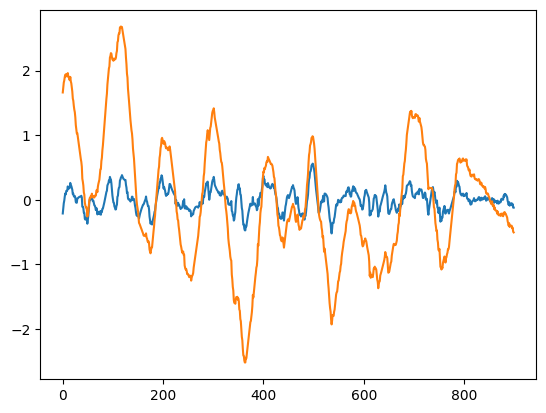

In [4]:
t = transformers.PolarCoordinates(mode='angle')
t = transformers.LocalMeanSubtract(k=15)
X_ = t.fit_transform(X_train)
plt.plot(X_[0, 0, :])
plt.plot(X_train[0, 0, :])

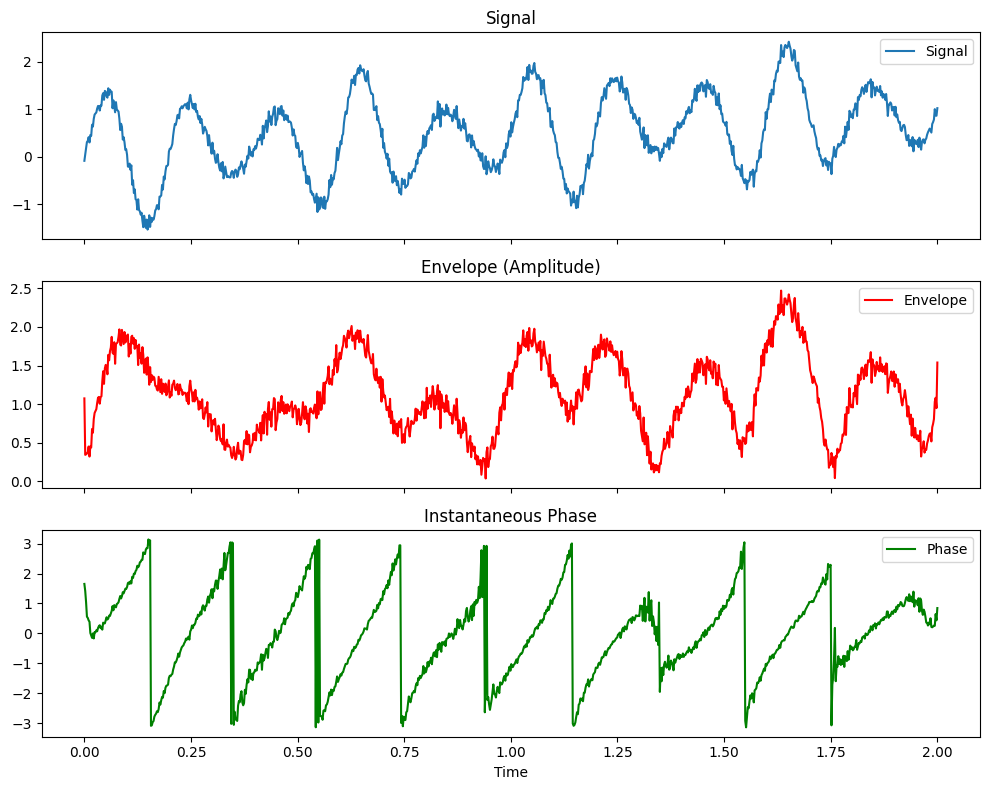

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert

# Time vector
t = np.linspace(0, 2, 1000)

# Modulated signal
signal = ((1 + 0.5*np.sin(4*np.pi*t)) * np.sin(10*np.pi*t)) + np.random.randn(len(t)) * 0.1 + t*0.5

# Compute analytic signal
analytic_signal = hilbert(signal)
envelope = np.abs(analytic_signal)
phase = np.angle(analytic_signal)

# Plot
fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

axs[0].plot(t, signal, label='Signal')
axs[0].set_title("Signal")
axs[0].legend()

axs[1].plot(t, envelope, 'r', label='Envelope')
axs[1].set_title("Envelope (Amplitude)")
axs[1].legend()

axs[2].plot(t, phase, 'g', label='Phase')
axs[2].set_title("Instantaneous Phase")
axs[2].legend()

plt.xlabel("Time")
plt.tight_layout()
plt.show()


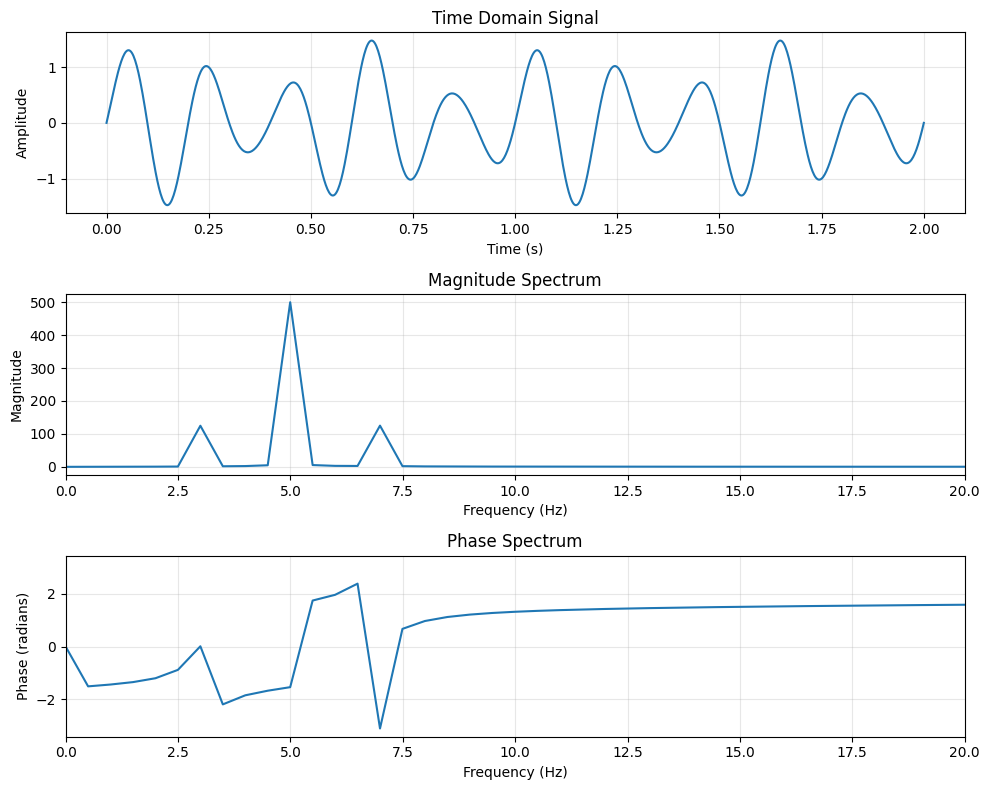

Dominant frequencies:
  4.99 Hz: magnitude 499.7
  6.99 Hz: magnitude 125.1
  3.00 Hz: magnitude 124.8
  5.49 Hz: magnitude 5.3
  4.50 Hz: magnitude 4.7


In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Time vector
t = np.linspace(0, 2, 1000)
fs = 1 / (t[1] - t[0])  # Sampling frequency

# Signal (same as before)
signal = (1 + 0.5*np.sin(4*np.pi*t)) * np.sin(10*np.pi*t)

# Compute FFT
fft_values = np.fft.fft(signal)
fft_freq = np.fft.fftfreq(len(signal), 1/fs)

# Get magnitude and phase
magnitude = np.abs(fft_values)
phase = np.angle(fft_values)

# Only plot positive frequencies (spectrum is symmetric)
pos_mask = fft_freq >= 0
freq_pos = fft_freq[pos_mask]
mag_pos = magnitude[pos_mask]
phase_pos = phase[pos_mask]

# Plot
fig, axs = plt.subplots(3, 1, figsize=(10, 8))

# Original signal
axs[0].plot(t, signal)
axs[0].set_title("Time Domain Signal")
axs[0].set_xlabel("Time (s)")
axs[0].set_ylabel("Amplitude")
axs[0].grid(True, alpha=0.3)

# Magnitude spectrum
axs[1].plot(freq_pos, mag_pos)
axs[1].set_title("Magnitude Spectrum")
axs[1].set_xlabel("Frequency (Hz)")
axs[1].set_ylabel("Magnitude")
axs[1].set_xlim([0, 20])  # Focus on relevant frequencies
axs[1].grid(True, alpha=0.3)

# Phase spectrum
axs[2].plot(freq_pos, phase_pos)
axs[2].set_title("Phase Spectrum")
axs[2].set_xlabel("Frequency (Hz)")
axs[2].set_ylabel("Phase (radians)")
axs[2].set_xlim([0, 20])
axs[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print dominant frequencies
peaks = np.argsort(mag_pos)[-5:][::-1]  # Top 5 peaks
print("Dominant frequencies:")
for i in peaks:
    print(f"  {freq_pos[i]:.2f} Hz: magnitude {mag_pos[i]:.1f}")

In [10]:
t

array([0.        , 0.002002  , 0.004004  , 0.00600601, 0.00800801,
       0.01001001, 0.01201201, 0.01401401, 0.01601602, 0.01801802,
       0.02002002, 0.02202202, 0.02402402, 0.02602603, 0.02802803,
       0.03003003, 0.03203203, 0.03403403, 0.03603604, 0.03803804,
       0.04004004, 0.04204204, 0.04404404, 0.04604605, 0.04804805,
       0.05005005, 0.05205205, 0.05405405, 0.05605606, 0.05805806,
       0.06006006, 0.06206206, 0.06406406, 0.06606607, 0.06806807,
       0.07007007, 0.07207207, 0.07407407, 0.07607608, 0.07807808,
       0.08008008, 0.08208208, 0.08408408, 0.08608609, 0.08808809,
       0.09009009, 0.09209209, 0.09409409, 0.0960961 , 0.0980981 ,
       0.1001001 , 0.1021021 , 0.1041041 , 0.10610611, 0.10810811,
       0.11011011, 0.11211211, 0.11411411, 0.11611612, 0.11811812,
       0.12012012, 0.12212212, 0.12412412, 0.12612613, 0.12812813,
       0.13013013, 0.13213213, 0.13413413, 0.13613614, 0.13813814,
       0.14014014, 0.14214214, 0.14414414, 0.14614615, 0.14814

In [ ]:
sddsfs=Dfsfd

In [ ]:
m = MultiRocketHydraClassifier(n_jobs=-1, random_state=random_state)
accuracy_score(y_test, m.fit(X_train, y_train).predict(X_test))

In [ ]:
m = aeon_make_pipeline(
    transformers.DownsampleTransformer(proportion=0.5),
    MultiRocketHydraClassifier(n_jobs=-1, random_state=random_state)
)
accuracy_score(y_test, m.fit(X_train, y_train).predict(X_test))

In [ ]:
m = aeon_make_pipeline(
    transformers.Difference(),
    MultiRocketHydraClassifier(n_jobs=-1, random_state=random_state)
)
accuracy_score(y_test, m.fit(X_train, y_train).predict(X_test))

In [ ]:
m = aeon_make_pipeline(
    transformers.CumSum(),
    MultiRocketHydraClassifier(n_jobs=-1, random_state=random_state)
)
accuracy_score(y_test, m.fit(X_train, y_train).predict(X_test))